# Sea-ice Integrated Ice-Edge Error (IIEE)

The metric computes the monthly climatological annual cycle of Integrated Ice-Edge Error
(IIEE) between observational and model sea ice concentration datasets.

The `calc_iiee_annual_cycle` function of the PMP subsets the input datasets to the requested time range, computes
monthly climatologies, evaluates IIEE for each month, and optionally saves
monthly comparison plots plus a seasonal-cycle summary plot.

Reference:

* Goessling, H. F., et al. 2016: Predictability of the Arctic sea ice edge, Geophys. Res. Lett., 43, 1642–1650, doi:10.1002/2015GL067232.
* Watts et al. 2021: A Spatial Evaluation of Arctic Sea Ice and Regional Limitations in CMIP6 Historical Simulations. Journal of Climate, 34, 6399-6420, DOI: 10.1175/JCLI-D-20-0491.1

## Prepare input dataset
* The demo data can be download as a part of the [PMP Demo 0 Notebook](https://pcmdi.github.io/pcmdi_metrics/examples/Demo_0_download_data.html). 
* In this demo, we are usig OSI-SAF as observation and E3SM-1-0 as a sample model output to evaluation against the observation. 
* Dataset can be loaded as `xarray.dataset` using `open_dataset` or `open_mfdataset` of either `xarray` or `xcdat`. 

In [1]:
import xarray as xr

ds_obs_nh = xr.open_dataset("demo_data/misc_demo_data/ocn/ice_conc_nh_ease2-250_cdr-v3p0_198801-202012.nc")
ds_obs_sh = xr.open_dataset("demo_data/misc_demo_data/ocn/ice_conc_sh_ease2-250_cdr-v3p0_198801-202012.nc")
ds_model = xr.open_mfdataset("demo_data/CMIP5_demo_timeseries/historical/ice/mon/siconc_SImon_E3SM-1-0_historical_r1i1p1f1_*_*.nc")

## Run the API

Load the API first:

More description for the API can be found at [here](../generated/pcmdi_metrics.sea_ice.calc_iiee_annual_cycle.html#pcmdi_metrics.sea_ice.calc_iiee_annual_cycle).

In [2]:
from pcmdi_metrics.sea_ice import calc_iiee_annual_cycle

### Arctic

In [3]:
result_nh = calc_iiee_annual_cycle(
        ds_obs=ds_obs_nh,
        ds_model=ds_model,
        obs_data_var="ice_conc",
        model_data_var="siconc",
        syear=2010,
        eyear=2014,
        save_dir="output_nh",
        identifier="E3SM-1-0_r1i1p1f1_NH"
    )

### Antarctic

In [4]:
result_sh = calc_iiee_annual_cycle(
        ds_obs=ds_obs_sh,
        ds_model=ds_model,
        obs_data_var="ice_conc",
        model_data_var="siconc",
        syear=2010,
        eyear=2014,
        save_dir="output_sh",
        identifier="E3SM-1-0_r1i1p1f1_SH"
    )

## Results

`result` is a Python Dictionary containing metadata and monthly IIEE metric values. Running the above API also generates diagnostics outputs as PNG files in the directory given as `save_dir`.

In [5]:
result_nh

{'metadata': {'start_year': 2010,
  'end_year': 2014,
  'obs_variable': 'ice_conc',
  'model_variable': 'siconc',
  'ice_threshold_percent': 15.0,
  'grid_cell_area_km2': 625.0,
  'obs_lat_name': 'lat',
  'obs_lon_name': 'lon',
  'model_lat_name': 'lat',
  'model_lon_name': 'lon'},
 'metrics': {1: {'iiee_overestimated_km2': 1933750.0,
   'iiee_underestimated_km2': 803125.0,
   'iiee_total_area_km2': 2736875.0},
  2: {'iiee_overestimated_km2': 2708125.0,
   'iiee_underestimated_km2': 840625.0,
   'iiee_total_area_km2': 3548750.0},
  3: {'iiee_overestimated_km2': 2766250.0,
   'iiee_underestimated_km2': 670000.0,
   'iiee_total_area_km2': 3436250.0},
  4: {'iiee_overestimated_km2': 2776250.0,
   'iiee_underestimated_km2': 618125.0,
   'iiee_total_area_km2': 3394375.0},
  5: {'iiee_overestimated_km2': 2182500.0,
   'iiee_underestimated_km2': 531875.0,
   'iiee_total_area_km2': 2714375.0},
  6: {'iiee_overestimated_km2': 1669375.0,
   'iiee_underestimated_km2': 500625.0,
   'iiee_total_are

### Diagnostics

#### Arctic

##### Map of simulated/observed sea-ice and the area of over/under-estimation

In [6]:
!ls output_nh

sic_iiee_E3SM-1-0_r1i1p1f1_NH_line_plot.png
sic_iiee_E3SM-1-0_r1i1p1f1_NH_month_01.png
sic_iiee_E3SM-1-0_r1i1p1f1_NH_month_02.png
sic_iiee_E3SM-1-0_r1i1p1f1_NH_month_03.png
sic_iiee_E3SM-1-0_r1i1p1f1_NH_month_04.png
sic_iiee_E3SM-1-0_r1i1p1f1_NH_month_05.png
sic_iiee_E3SM-1-0_r1i1p1f1_NH_month_06.png
sic_iiee_E3SM-1-0_r1i1p1f1_NH_month_07.png
sic_iiee_E3SM-1-0_r1i1p1f1_NH_month_08.png
sic_iiee_E3SM-1-0_r1i1p1f1_NH_month_09.png
sic_iiee_E3SM-1-0_r1i1p1f1_NH_month_10.png
sic_iiee_E3SM-1-0_r1i1p1f1_NH_month_11.png
sic_iiee_E3SM-1-0_r1i1p1f1_NH_month_12.png
sic_iiee_E3SM-1-0_r1i1p1f1_NH_month_all.png


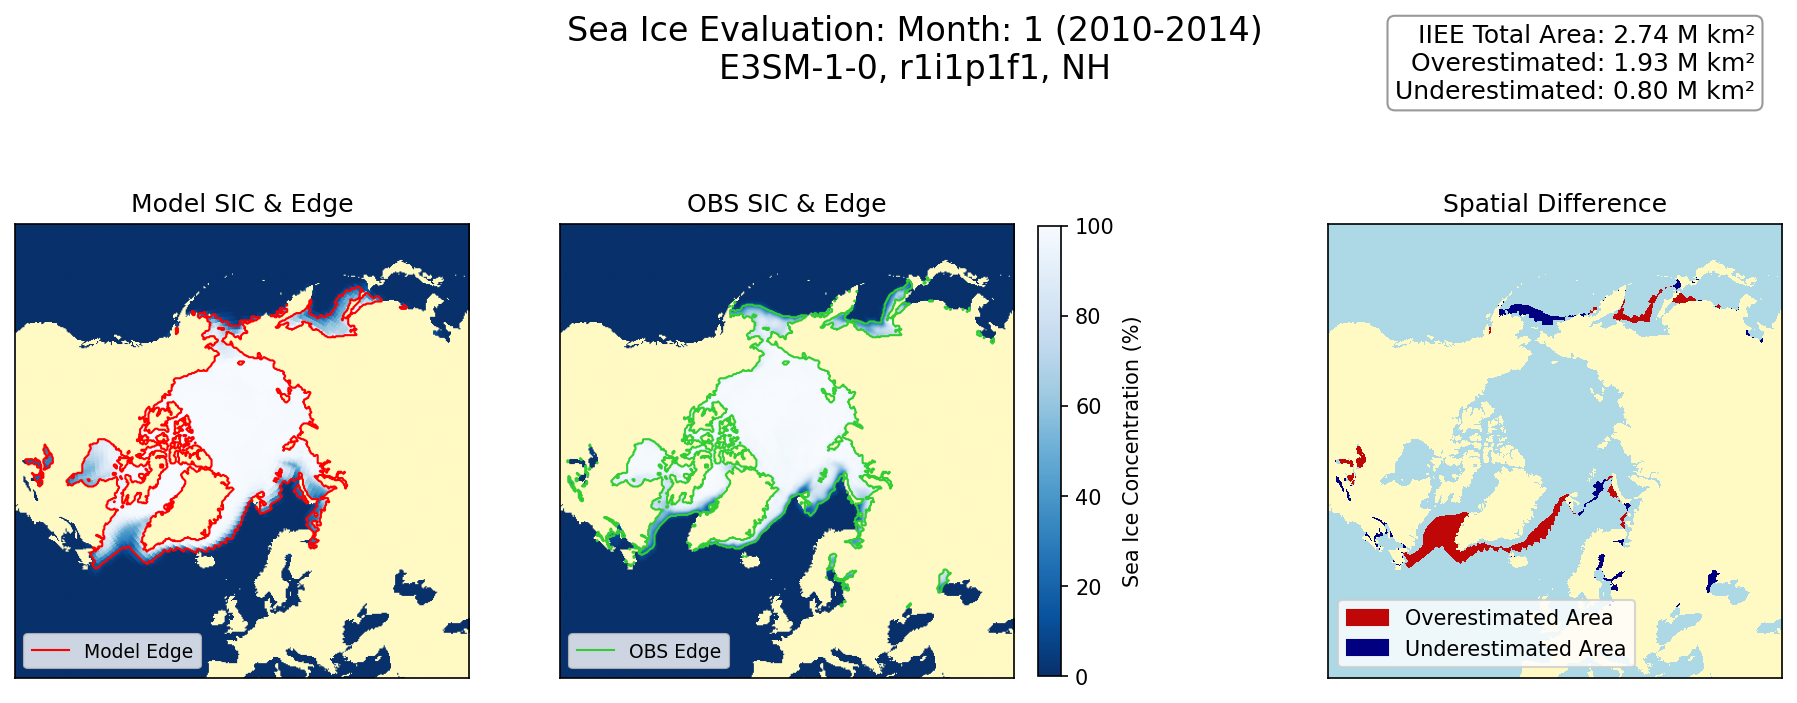

In [7]:
from IPython.display import Image, display
display(Image(filename='output_nh/sic_iiee_E3SM-1-0_r1i1p1f1_NH_month_01.png'))

The API also generates maps for all individual months of thier climatology:

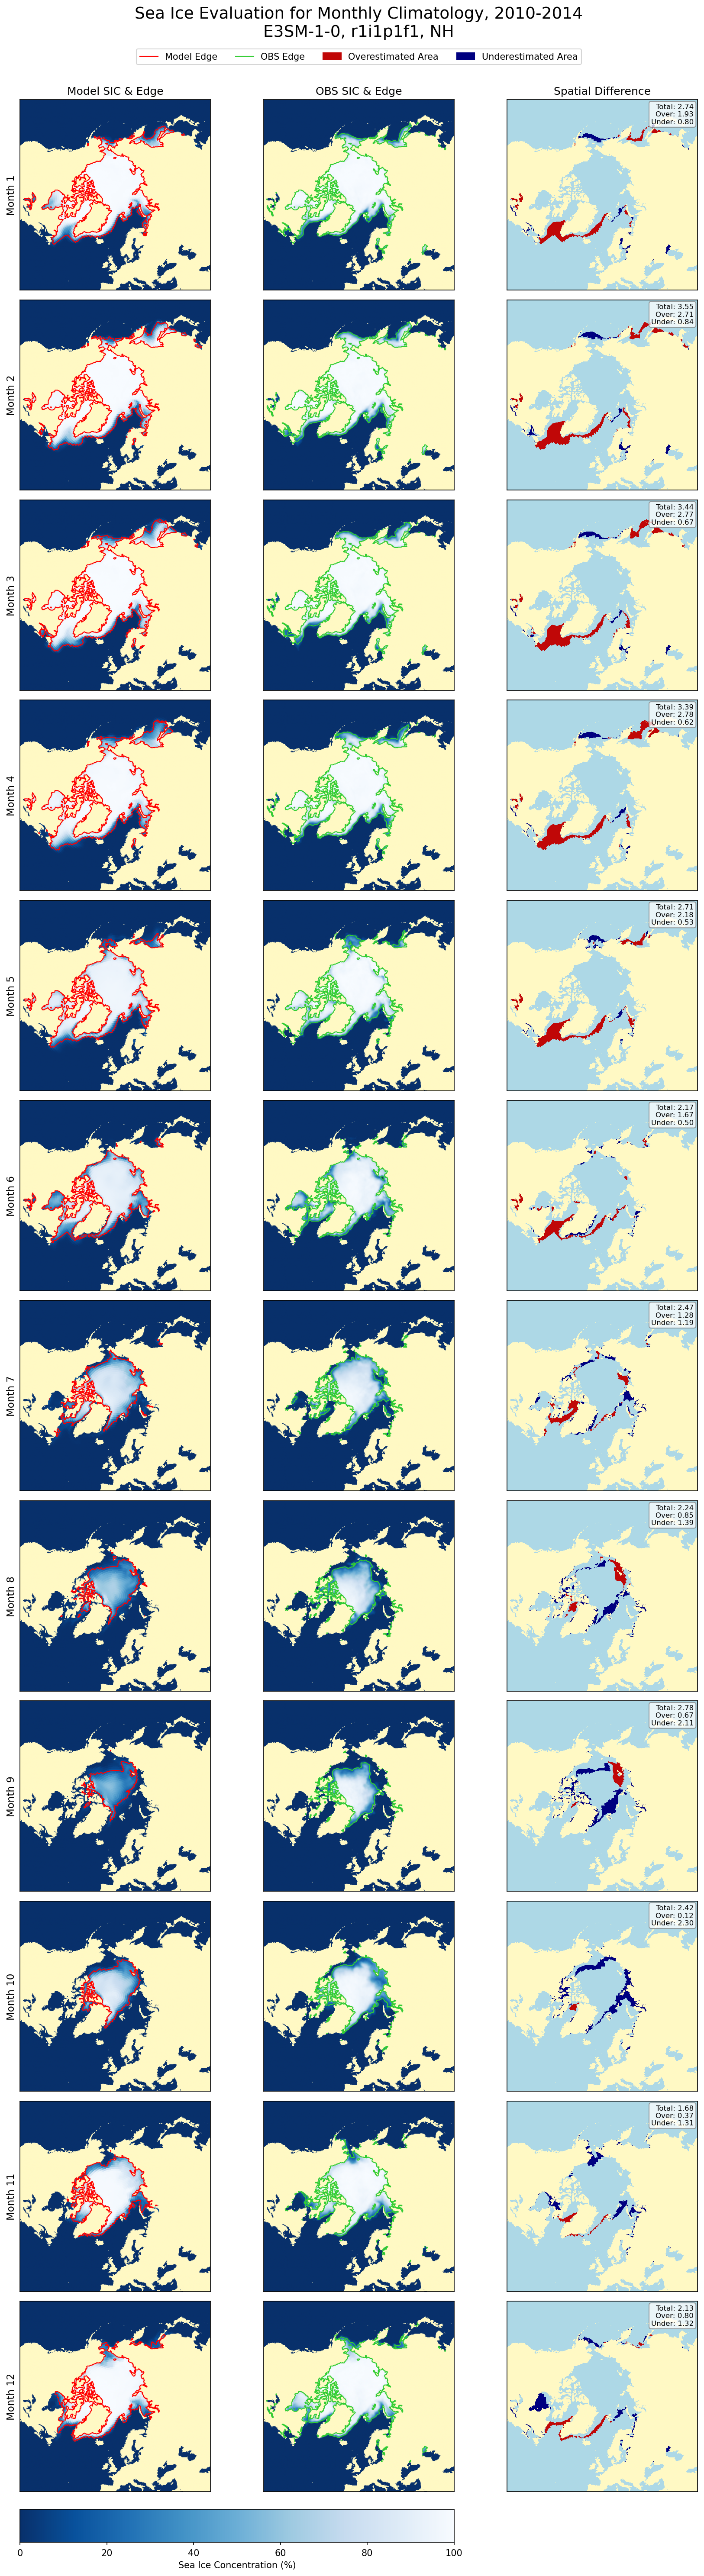

In [8]:
display(Image(filename='output_nh/sic_iiee_E3SM-1-0_r1i1p1f1_NH_month_all.png'))

##### Line plot

The API also generates a line plot for the annual cycle.

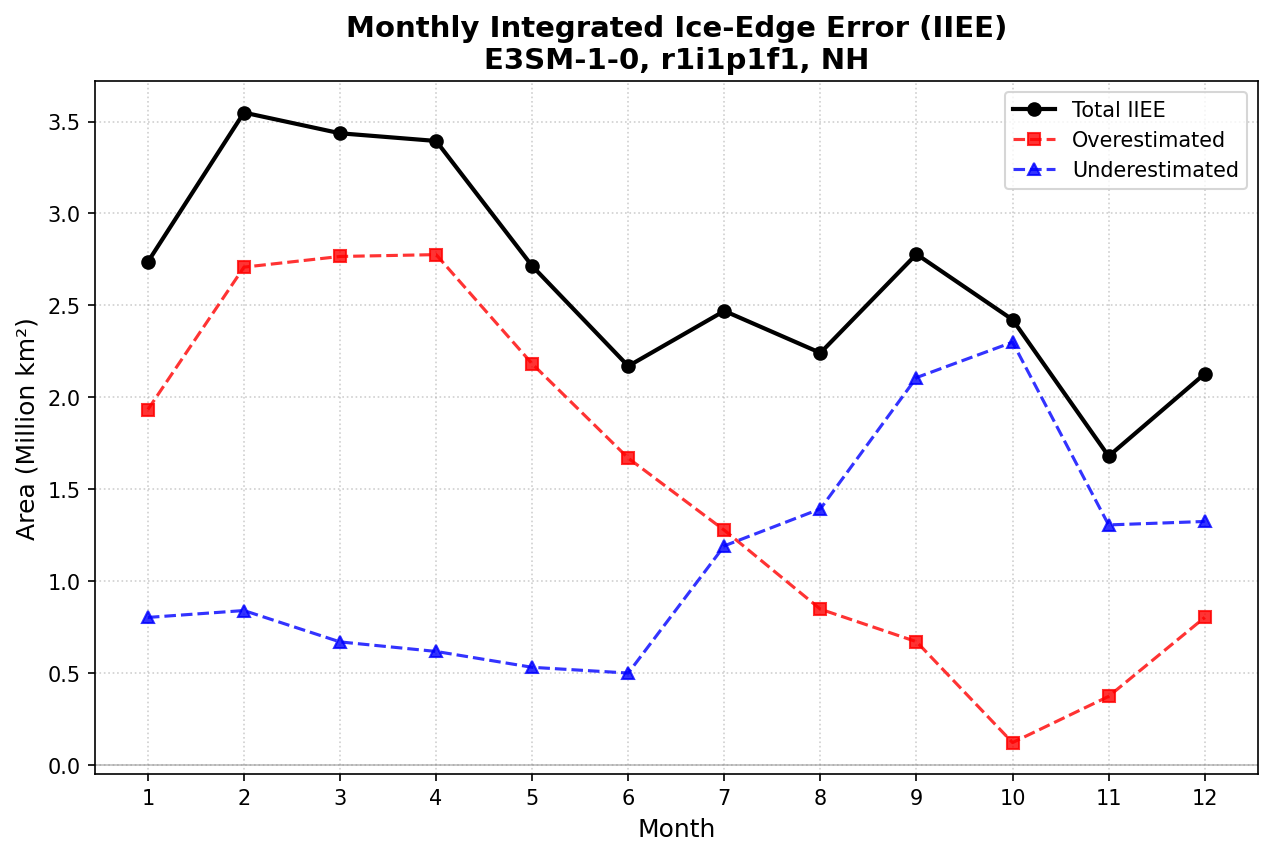

In [9]:
display(Image(filename='output_nh/sic_iiee_E3SM-1-0_r1i1p1f1_NH_line_plot.png'))

#### Antarctic

In [10]:
!ls output_sh/

sic_iiee_E3SM-1-0_r1i1p1f1_SH_line_plot.png
sic_iiee_E3SM-1-0_r1i1p1f1_SH_month_01.png
sic_iiee_E3SM-1-0_r1i1p1f1_SH_month_02.png
sic_iiee_E3SM-1-0_r1i1p1f1_SH_month_03.png
sic_iiee_E3SM-1-0_r1i1p1f1_SH_month_04.png
sic_iiee_E3SM-1-0_r1i1p1f1_SH_month_05.png
sic_iiee_E3SM-1-0_r1i1p1f1_SH_month_06.png
sic_iiee_E3SM-1-0_r1i1p1f1_SH_month_07.png
sic_iiee_E3SM-1-0_r1i1p1f1_SH_month_08.png
sic_iiee_E3SM-1-0_r1i1p1f1_SH_month_09.png
sic_iiee_E3SM-1-0_r1i1p1f1_SH_month_10.png
sic_iiee_E3SM-1-0_r1i1p1f1_SH_month_11.png
sic_iiee_E3SM-1-0_r1i1p1f1_SH_month_12.png
sic_iiee_E3SM-1-0_r1i1p1f1_SH_month_all.png


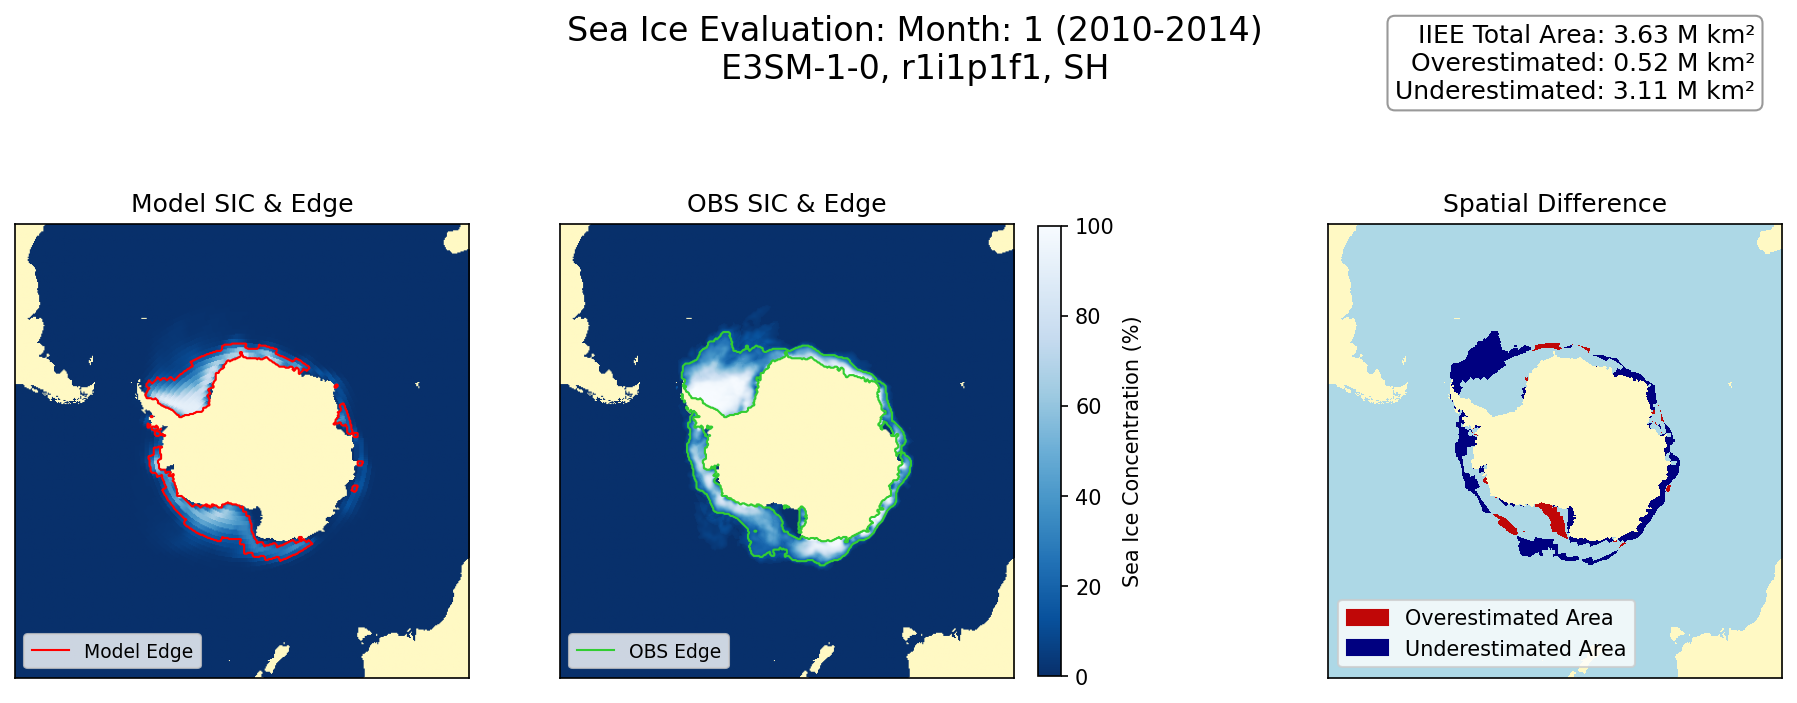

In [11]:
display(Image(filename='output_sh/sic_iiee_E3SM-1-0_r1i1p1f1_SH_month_01.png'))

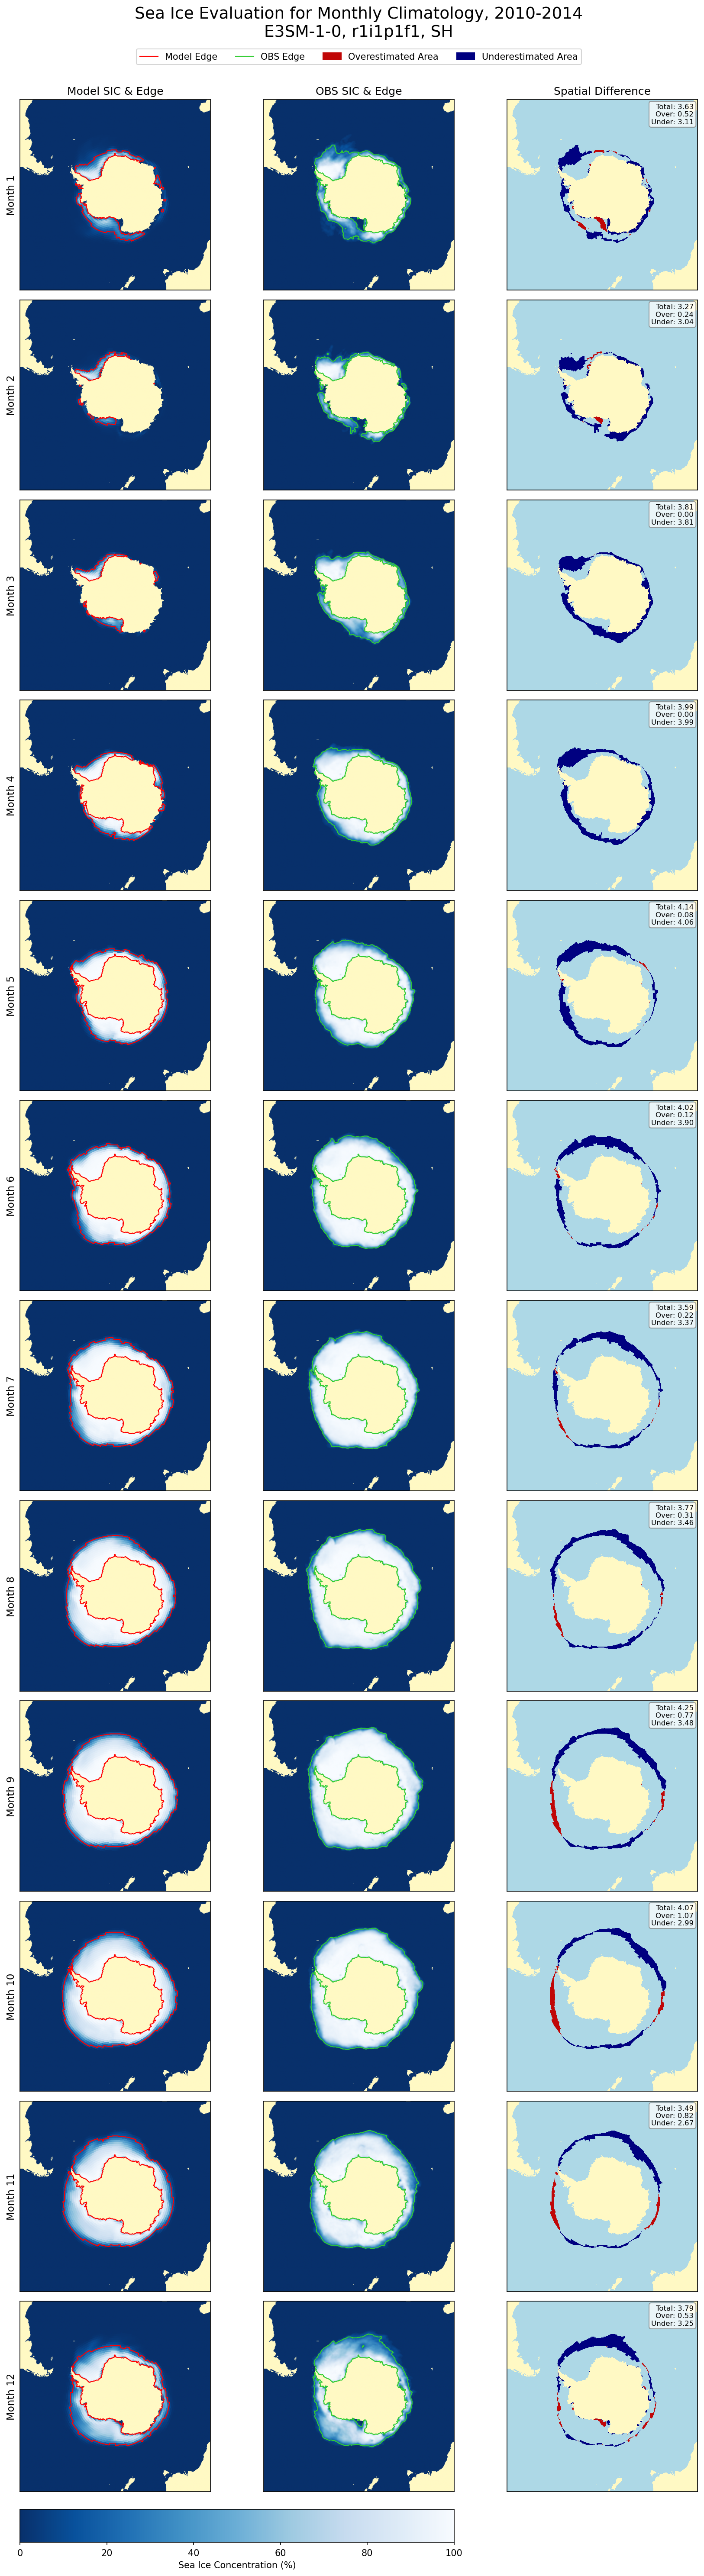

In [12]:
display(Image(filename='output_sh/sic_iiee_E3SM-1-0_r1i1p1f1_SH_month_all.png'))

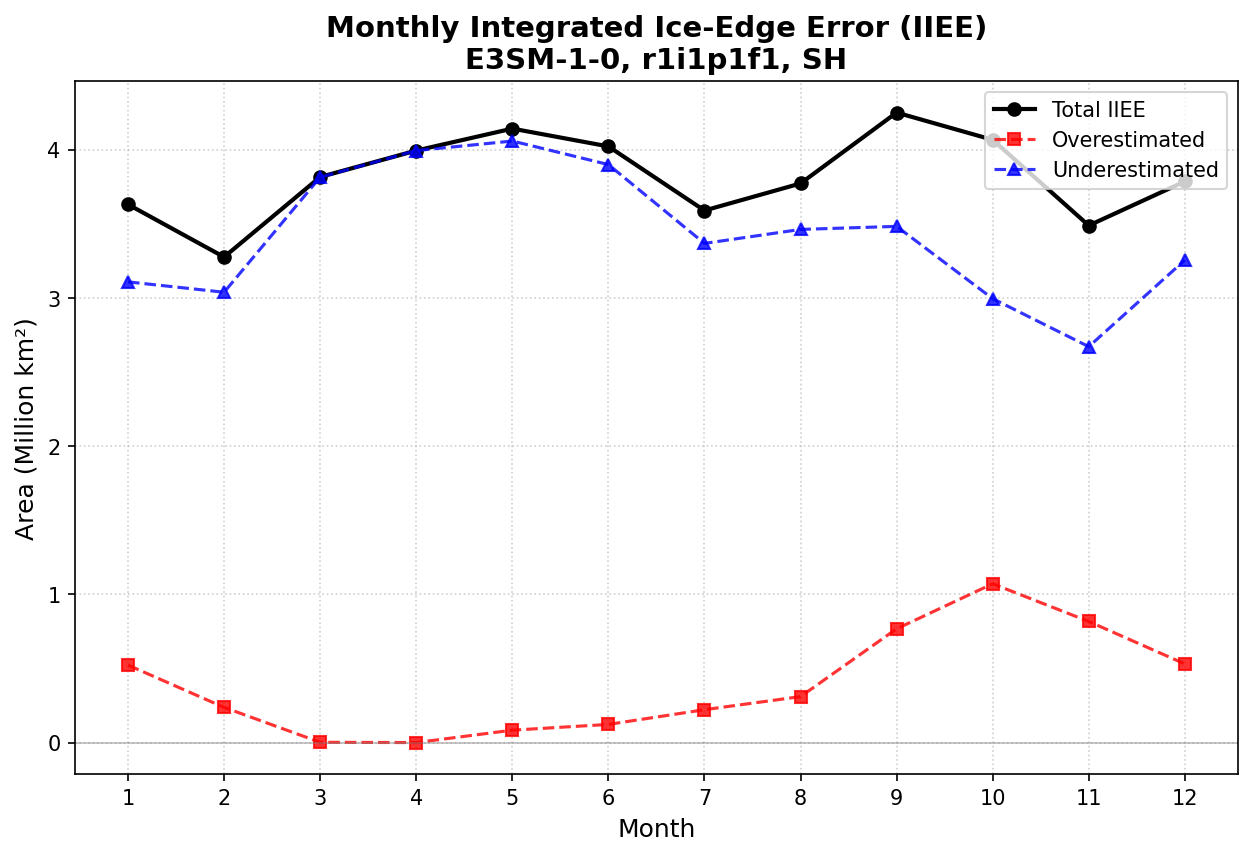

In [13]:
display(Image(filename='output_sh/sic_iiee_E3SM-1-0_r1i1p1f1_SH_line_plot.png'))